In [117]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [407]:
import sys

In [78]:
from MLO.utils import AP, NonAP

In [67]:
from pathlib import Path

import numpy as np

from MLO.env import TestBed, Experiment
from Algorithms.exp3 import EXP3

import pickle

In [68]:
from MLO.env import build_arms_for_ap

In [234]:
n_aps = 4
m_nonaps = 20
area_size = 10
d1 = 10 * np.sqrt(2)  # Ensure that all non-APs have at least one AP in visibility.

# The horizon is divided into two parts (T1 and T2).
n_links = 2 # No of links available per AP.
horizon = 200_000
T1 = 75_000
T2 = horizon-T1
w0 = 32
m = 3
seed = 1

In [369]:
# Create the test bed with just one link per AP (Let each non AP associate with an AP first.)
test_bed = TestBed(n_aps=n_aps, m_nonaps=m_nonaps, n_links=1, area_size=area_size, d1=d1, seed=seed)

In [370]:
aps = test_bed.aps
non_aps = test_bed.nonaps

In [371]:
non_aps[0].chosen_arms

[]

In [373]:
# Assign learners to the non_aps.
learner = EXP3
for id, non_ap in enumerate(non_aps):
    n_actions = len(non_ap.available_actions)
    args = {"gamma": 0.1, "seed":id+1}
    non_ap.learner = learner(n_actions, **args)

In [374]:
args = {'w0': w0, 'm': m, 'store_rewards': True}
experiment = Experiment(aps, non_aps, T1, 1, **args)
experiment.run()

iter: 0, probs: [0.25 0.25 0.25 0.25]
iter: 74999, probs: [0.02523605 0.91494226 0.03481448 0.02500721]


In [375]:
# To see convergence and percentage convergence
for n_ap in non_aps:
    highest_prob_idx = np.argmax(n_ap.learner.probs)
    print(f'best arm {n_ap.available_actions[highest_prob_idx]}, probability: {n_ap.learner.probs[highest_prob_idx]}', )

best arm (1, 0), probability: 0.9149422558841049
best arm (2, 0), probability: 0.8239824447665702
best arm (1, 0), probability: 0.9249518350211029
best arm (0, 0), probability: 0.9249192782750196
best arm (0, 0), probability: 0.9115700383872398
best arm (1, 0), probability: 0.9237920994251173
best arm (2, 0), probability: 0.9248787019686114
best arm (2, 0), probability: 0.9249975268550878
best arm (1, 0), probability: 0.9027903778817328
best arm (3, 0), probability: 0.9222986667076003
best arm (0, 0), probability: 0.9248608954206131
best arm (1, 0), probability: 0.91627407659962
best arm (2, 0), probability: 0.9249997459189179
best arm (3, 0), probability: 0.9241590818823263
best arm (2, 0), probability: 0.9232554101019268
best arm (0, 0), probability: 0.9243024308616933
best arm (3, 0), probability: 0.9235920137371474
best arm (0, 0), probability: 0.8834564037503289
best arm (3, 0), probability: 0.9205307151079212
best arm (3, 0), probability: 0.9238227303530833


In [376]:
# Copy the APs and Non APs to store data
aps2 = []
non_aps2 = []
for i in range(n_aps):
    ap = AP(aps[i].id, aps[i].pos)
    aps2.append(ap)

for i in range(m_nonaps):
    non_ap = NonAP(non_aps[i].id, non_aps[i].pos)
    non_aps2.append(non_ap)

In [377]:
for n_ap in non_aps:
    n_ap.available_actions = []
    for id in range(n_aps):
        arm_space = build_arms_for_ap(id, 1)
        n_ap.visible_aps.append(id)
        n_ap.available_actions.extend(arm_space)

In [378]:
for ap in aps2:
    ap.associations = {}
    ap.n_association_per_link = [0] * 3

In [379]:
for id, non_ap in enumerate(non_aps2):
    highest_prob_idx = np.argmax(non_aps[id].learner.probs)
    assc_ap_id = non_aps[id].available_actions[highest_prob_idx][0]

    # Make the associated AP the only available AP and build the arm space accordingly.
    non_ap.visible_aps = [assc_ap_id]
    non_ap.curr_act_id = None
    non_ap.available_actions = build_arms_for_ap(assc_ap_id, n_links)

    # Update the learner.
    n_actions = len(non_ap.available_actions)
    args = {"gamma": 0.1, "seed":id+1}
    non_ap.learner = learner(n_actions, **args)

In [380]:
args = {'w0': w0, 'm': m, 'store_rewards': True}
experiment = Experiment(aps2, non_aps2, T2, 1, **args)
experiment.run()

iter: 0, probs: [0.33333333 0.33333333 0.33333333]
iter: 124999, probs: [0.03333333 0.03333333 0.93333333]


In [381]:
for n_ap in non_aps2:
    highest_prob_idx = np.argmax(n_ap.learner.probs)
    print(f'best arm {n_ap.available_actions[highest_prob_idx]}, probability: {n_ap.learner.probs[highest_prob_idx]}', )

best arm (1, 2), probability: 0.9333333333333333
best arm (2, 2), probability: 0.9333333333333333
best arm (1, 2), probability: 0.9333333333333333
best arm (0, 2), probability: 0.9333333333333333
best arm (0, 2), probability: 0.9333333333333333
best arm (1, 2), probability: 0.9333333333333333
best arm (2, 2), probability: 0.9333333333333333
best arm (2, 2), probability: 0.9333333333333333
best arm (1, 2), probability: 0.9333333333333333
best arm (3, 2), probability: 0.9333333333333333
best arm (0, 2), probability: 0.9333333333333333
best arm (1, 2), probability: 0.9333333333333333
best arm (2, 2), probability: 0.9333333333333333
best arm (3, 2), probability: 0.9333333333333333
best arm (2, 2), probability: 0.9333333333333333
best arm (0, 2), probability: 0.9333333333333333
best arm (3, 2), probability: 0.9333333333333333
best arm (0, 2), probability: 0.9333333333333333
best arm (3, 2), probability: 0.9333333333333333
best arm (3, 2), probability: 0.9333333333333333


In [401]:
# Expand the arm space corresponding to the UEs.
new_arm_space = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (3, 2)]
arm_space_len = len(new_arm_space)

for non_ap in non_aps:
    new_arm_idx = [new_arm_space.index(arm) for arm in non_ap.available_actions]
    for t in range(1):
        # Chosen arm by the non_ap at t (old arm space)
        id = non_ap.chosen_arms[t]
        id_new = new_arm_idx[id]
        non_ap.chosen_arms[t] = id_new

        # Store the probs corresponding to new arm index.
        new_probs = np.zeros(arm_space_len)
        
        for i, prob in enumerate(non_ap.learner.save_probs[t]):
            new_idx = new_arm_idx[i]
            new_probs[new_idx] = prob

        non_ap.learner.save_probs[t] = new_probs

    non_ap.available_actions = new_arm_space

In [384]:
for non_ap in non_aps2:
    new_arm_idx = [new_arm_space.index(arm) for arm in non_ap.available_actions]
    for t in range(T2):
        # Chosen arm by the non_ap at t (old arm space)
        id = non_ap.chosen_arms[t]
        id_new = new_arm_idx[id]
        non_ap.chosen_arms[t] = id_new

        # Store the probs corresponding to new arm index.
        new_probs = np.zeros(arm_space_len)
        
        for i, prob in enumerate(non_ap.learner.save_probs[t]):
            new_idx = new_arm_idx[i]
            new_probs[new_idx] = prob

        non_ap.learner.save_probs[t] = new_probs

    non_ap.available_actions = new_arm_space

**Calculating regret**

In [385]:
import matplotlib.pyplot as plt

In [386]:
from MLO.nstr import params

In [387]:
from MLO import n_player_nash_files, regret
from MLO.n_player_nash_files import build_thr_table
from MLO.regret import cal_per_step_regret

In [388]:
N, w0, m = 20, 32, 3
thr_table = build_thr_table(N, w0, m, params, True)

In [389]:
for non_ap1, non_ap2 in zip(non_aps, non_aps2):
    non_ap1.chosen_arms.extend(non_ap2.chosen_arms)
    non_ap1.rewards.extend(non_ap2.rewards)
    non_ap1.learner.save_probs.extend(non_ap2.learner.save_probs)

In [448]:
regret_hist1 = cal_per_step_regret(0, 4, non_aps, thr_table)

In [392]:
regret_hist2 = cal_per_step_regret(0, 4, non_aps2, thr_table)

In [393]:
sqrt_regret = np.sqrt(np.arange(1, horizon))

In [437]:
sqrt_regret

array([  1.        ,   1.41421356,   1.73205081, ..., 447.21024139,
       447.21135943, 447.21247746], shape=(199999,))

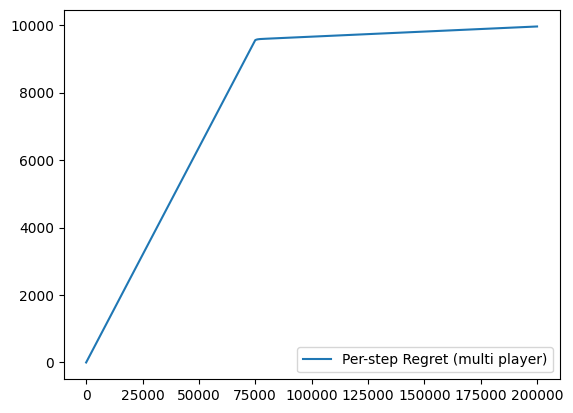

In [449]:
plt.plot(regret_hist1, label='Per-step Regret (multi player)')
# plt.plot(30*sqrt_regret, label='sqrt-regret')
# plt.plot(regret_hist2, label='Per-step Regret (multi player)')
plt.legend()
plt.show()

In [408]:
cwd = Path.cwd()

In [440]:
mlo2_path = str(cwd.parent.parent.parent / "MLO2")

In [441]:
# 2. Add it to sys.path if it is not already there
if mlo2_path not in sys.path:
    sys.path.insert(0, mlo2_path)

In [442]:
from env import MABEnvironment

In [453]:
with open(f'/home/kishan/Desktop/Kishan/Research/Codes/MLO2/ExperimentData/Experiment2/seed1_exp3_environment_data.pkl', 'rb') as f:
    env = pickle.load(f)

In [454]:
aps_exp3 = env.aps
non_aps_exp3 = env.nonaps

In [455]:
for n_ap in non_aps_exp3:
    highest_prob_idx = np.argmax(n_ap.learner.probs)
    print(f'best arm {n_ap.available_arms[highest_prob_idx]}, probability: {n_ap.learner.probs[highest_prob_idx]}', )

best arm (1, 2), probability: 0.908331770729815
best arm (2, 2), probability: 0.908328437896101
best arm (0, 2), probability: 0.9083332097503779
best arm (3, 2), probability: 0.9083333323905642
best arm (2, 2), probability: 0.9083333192670466
best arm (0, 2), probability: 0.9083114297666561
best arm (3, 2), probability: 0.9083333325553111
best arm (0, 2), probability: 0.9083324662794461
best arm (1, 2), probability: 0.9079297234355345
best arm (0, 2), probability: 0.9083332640515234
best arm (2, 2), probability: 0.9083269915786725
best arm (3, 2), probability: 0.9083333328738384
best arm (3, 2), probability: 0.9059575399618247
best arm (1, 2), probability: 0.9083267582515497
best arm (2, 2), probability: 0.9083332634929421
best arm (3, 2), probability: 0.9083333066169277
best arm (2, 2), probability: 0.9083330063310635
best arm (1, 2), probability: 0.9083332278258691
best arm (1, 2), probability: 0.9083328582141691
best arm (0, 2), probability: 0.9082946227589418


In [459]:
regret_hist_exp = cal_per_step_regret(0, 4, non_aps_exp3, thr_table)

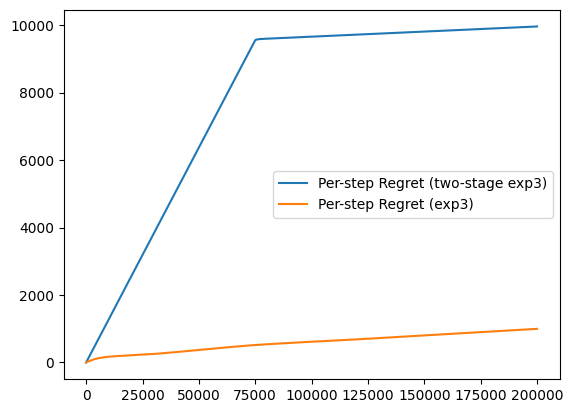

In [461]:
plt.plot(regret_hist1, label='Per-step Regret (two-stage exp3)')
plt.plot(regret_hist_exp, label='Per-step Regret (exp3)')
# plt.plot(30*sqrt_regret, label='sqrt-regret')
# plt.plot(regret_hist2, label='Per-step Regret (multi player)')
plt.legend()
plt.show()